In [1]:
# Cell 1: Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
import os
pd.set_option('display.max_columns', 200)
sns.set(style='whitegrid')

In [2]:
# Cell 2: Load data
DATA_PATH = "../data/sierraleone-bumbuna.csv"   # change to your file
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'], dayfirst=False)
df.sort_values('Timestamp', inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04:00,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05:00,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [3]:
# Cell 3: Basic profiling
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-04-30 12:00:30.000000768,2021-10-30 00:01:00,2022-01-29 06:00:45,2022-04-30 12:00:30,2022-07-30 18:00:15,2022-10-30 00:00:00,NaN
GHI,525600.0,201.957515,-19.5,-2.8,0.3,362.4,1499.0,298.49515
DNI,525600.0,116.376337,-7.8,-0.3,-0.1,107.0,946.0,218.652659
DHI,525600.0,113.720571,-17.9,-3.8,-0.1,224.7,892.0,158.946032
ModA,525600.0,206.643095,0.0,0.0,3.6,359.5,1507.0,300.896893
ModB,525600.0,198.114691,0.0,0.0,3.4,345.4,1473.0,288.889073
Tamb,525600.0,26.319394,12.3,23.1,25.3,29.4,39.9,4.398605
RH,525600.0,79.448857,9.9,68.7,85.4,96.7,100.0,20.520775
WS,525600.0,1.146113,0.0,0.0,0.8,2.0,19.2,1.239248
WSgust,525600.0,1.691606,0.0,0.0,1.6,2.6,23.9,1.617053


In [4]:
# Cell 4: Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.concat([missing, missing_pct.rename('pct')], axis=1).head(30)


,0,pct
Comments,525600,100.0
GHI,0,0.0
Timestamp,0,0.0
DNI,0,0.0
DHI,0,0.0
ModB,0,0.0
ModA,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


In [5]:
# Cell 5: Columns with >5% nulls
cols_gt5 = (missing_pct[missing_pct > 5]).index.tolist()
cols_gt5, missing_pct[cols_gt5]


(['Comments'],
 Comments    100.0
 dtype: float64)

In [6]:
# Cell 6: Data types & convert columns if necessary
# Example convert columns to numeric if they are read as strings
numeric_cols = ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','WSgust','BP','Precipitation','TModA','TModB']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


In [7]:
# Cell 7: Outlier detection using Z-score
z_cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']
z_cols = [c for c in z_cols if c in df.columns]
df_z = df.copy()
df_z['z_max'] = df_z[z_cols].apply(lambda row: np.nanmax(np.abs(stats.zscore(row, nan_policy='omit'))) if row.notna().any() else np.nan, axis=1)
outliers = df_z[df_z['z_max'] > 3]
len(outliers), outliers.head()


(0,
 Empty DataFrame
 Columns: [Timestamp, GHI, DNI, DHI, ModA, ModB, Tamb, RH, WS, WSgust, WSstdev, WD, WDstdev, BP, Cleaning, Precipitation, TModA, TModB, Comments, z_max]
 Index: [])

In [8]:
# Cell 8: Handling missing values (example strategy)
# Impute median for key columns, drop rows for essential timestamp missing etc.
key_cols = ['GHI','DNI','DHI','Tamb']
for c in key_cols:
    if c in df.columns:
        median_val = df[c].median()
        df[c] = df[c].fillna(median_val)
# For other numeric columns with <20% NaNs, fill median; else keep and document.
for c in numeric_cols:
    if c in df.columns:
        pct_null = df[c].isna().mean()
        if pct_null < 0.2:
            df[c] = df[c].fillna(df[c].median())


In [9]:
# Cell 9: Time-based features
df['date'] = df['Timestamp'].dt.date
df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['dayofweek'] = df['Timestamp'].dt.dayofweek


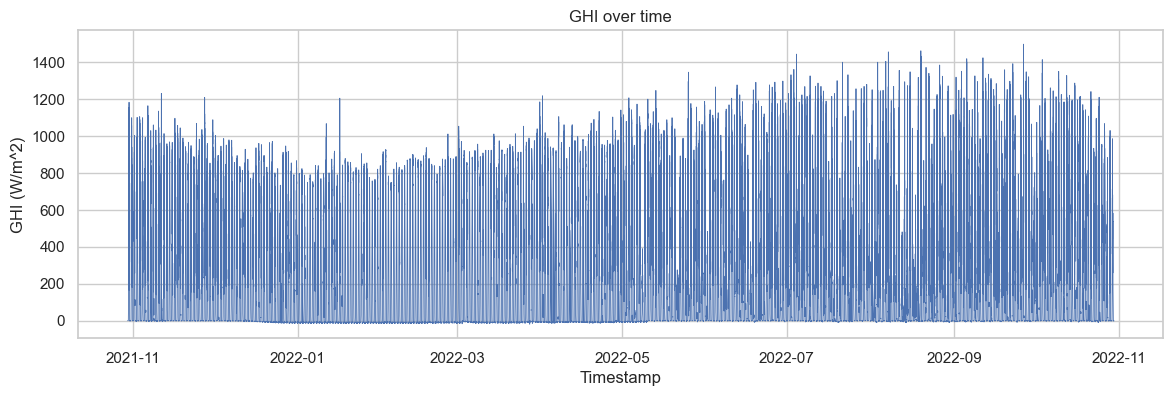

In [10]:
# Cell 10: Time series plots - GHI
plt.figure(figsize=(14,4))
plt.plot(df['Timestamp'], df['GHI'], linewidth=0.6)
plt.title('GHI over time')
plt.xlabel('Timestamp'); plt.ylabel('GHI (W/m^2)')
plt.show()


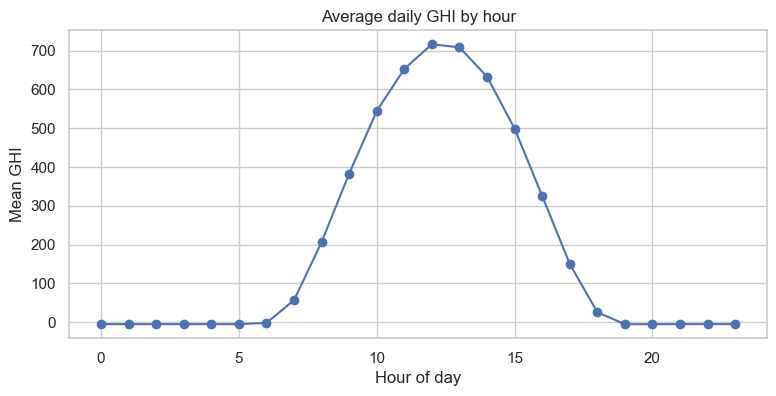

In [11]:
# Cell 11: Daily profile - average by hour
hourly = df.groupby('hour')['GHI'].mean()
plt.figure(figsize=(9,4))
hourly.plot(kind='line', marker='o')
plt.title('Average daily GHI by hour')
plt.xlabel('Hour of day'); plt.ylabel('Mean GHI')
plt.grid(True)
plt.show()


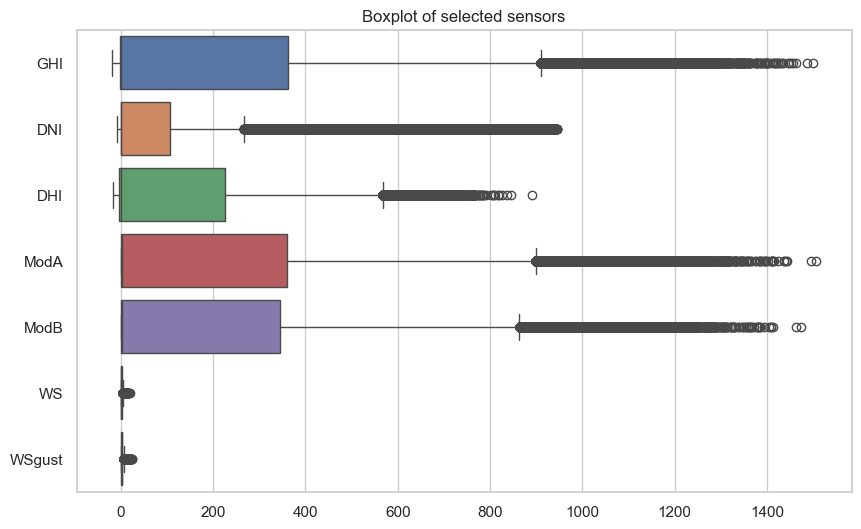

In [12]:
# Cell 12: Boxplots for key signals
plt.figure(figsize=(10,6))
sns.boxplot(data=df[z_cols], orient='h')
plt.title('Boxplot of selected sensors')
plt.show()


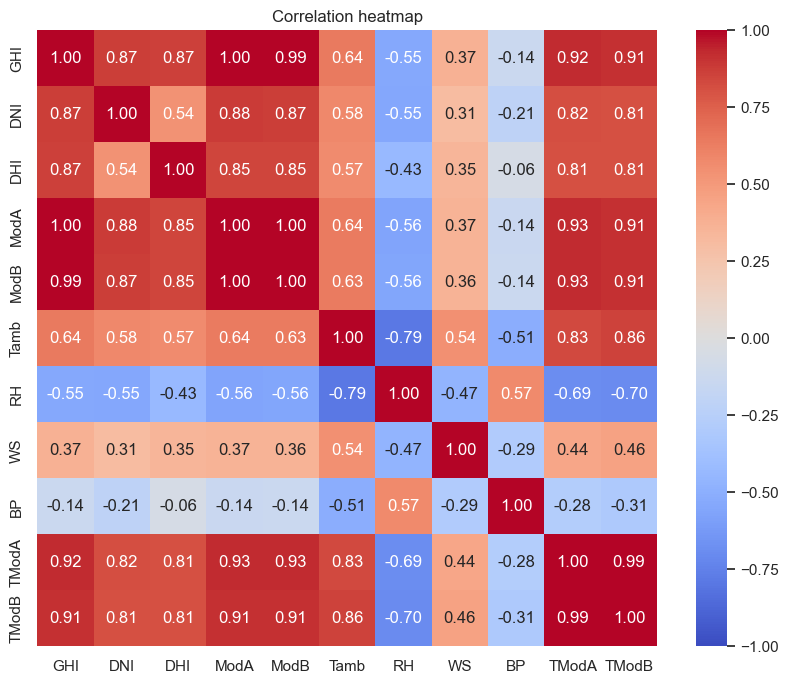

In [13]:
# Cell 13: Correlation heatmap
corr_cols = [c for c in ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','BP','TModA','TModB'] if c in df.columns]
plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()


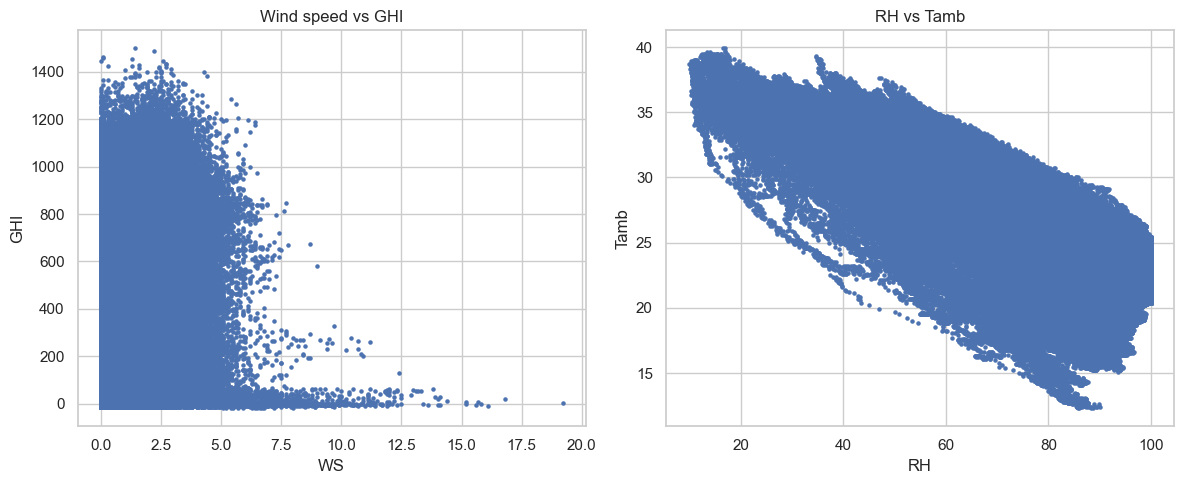

In [14]:
# Cell 14: Scatter plots - WS vs GHI, RH vs Tamb
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df['WS'], df['GHI'], s=5)
plt.xlabel('WS'); plt.ylabel('GHI'); plt.title('Wind speed vs GHI')
plt.subplot(1,2,2)
plt.scatter(df['RH'], df['Tamb'], s=5)
plt.xlabel('RH'); plt.ylabel('Tamb'); plt.title('RH vs Tamb')
plt.tight_layout()
plt.show()


,Cleaning,ModA,ModB
0,0,206.578599,198.038150
1,1,273.309252,277.231102


<Figure size 600x400 with 0 Axes>

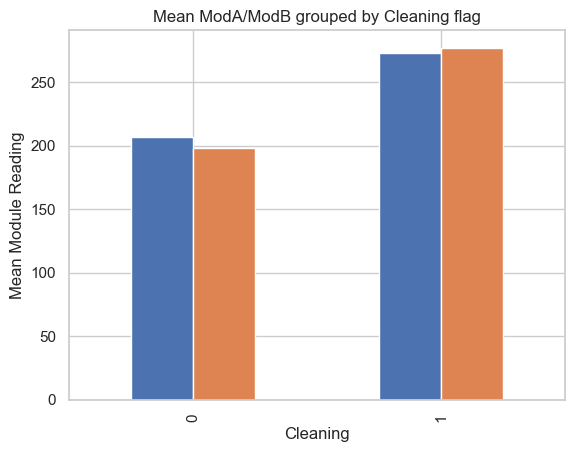

In [15]:
# Cell 15: Cleaning impact analysis (Cleaning column assumed 0/1)
if 'Cleaning' in df.columns:
    gp = df.groupby('Cleaning')[['ModA','ModB']].mean().reset_index()
    display(gp)
    plt.figure(figsize=(6,4))
    gp.set_index('Cleaning').plot(kind='bar', xlabel='Cleaning', ylabel='Mean Module Reading', legend=False)
    plt.title('Mean ModA/ModB grouped by Cleaning flag')
    plt.show()


In [16]:
# Cell 16: Save cleaned CSV (local, but DO NOT commit)
OUT_PATH = '../data/sierra_leone_clean.csv'
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
df.to_csv(OUT_PATH, index=False)
print('Saved cleaned CSV to', OUT_PATH)


Saved cleaned CSV to ../data/sierra_leone_clean.csv
